In [1]:
import numpy
import sklearn
import scipy
import pandas

print("numpy:", numpy.__version__)
print("sklearn working")

numpy: 1.26.4
sklearn working


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data from: C:\project IP\urbanizationoutput\Urbanization_Stats_2015_2020.csv
Loaded 87 records
Date range: 2015-01-08 → 2019-04-25

Using Kurunegala urbanization data from 2015 to 2020
Total records: 87

Train/Test Split: 73 training, 14 testing records

Training Prophet...


11:48:49 - cmdstanpy - INFO - Chain [1] start processing
11:48:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet → MAE: 53.891, RMSE: 66.041, R²: -0.608

Training ARIMA...
ARIMA(1,1,1) → MAE: 41.342, RMSE: 55.965, R²: -0.155

Training Random Forest...
Random Forest → MAE: 48.232, RMSE: 66.768, R²: -0.644

Running K-Means clustering...


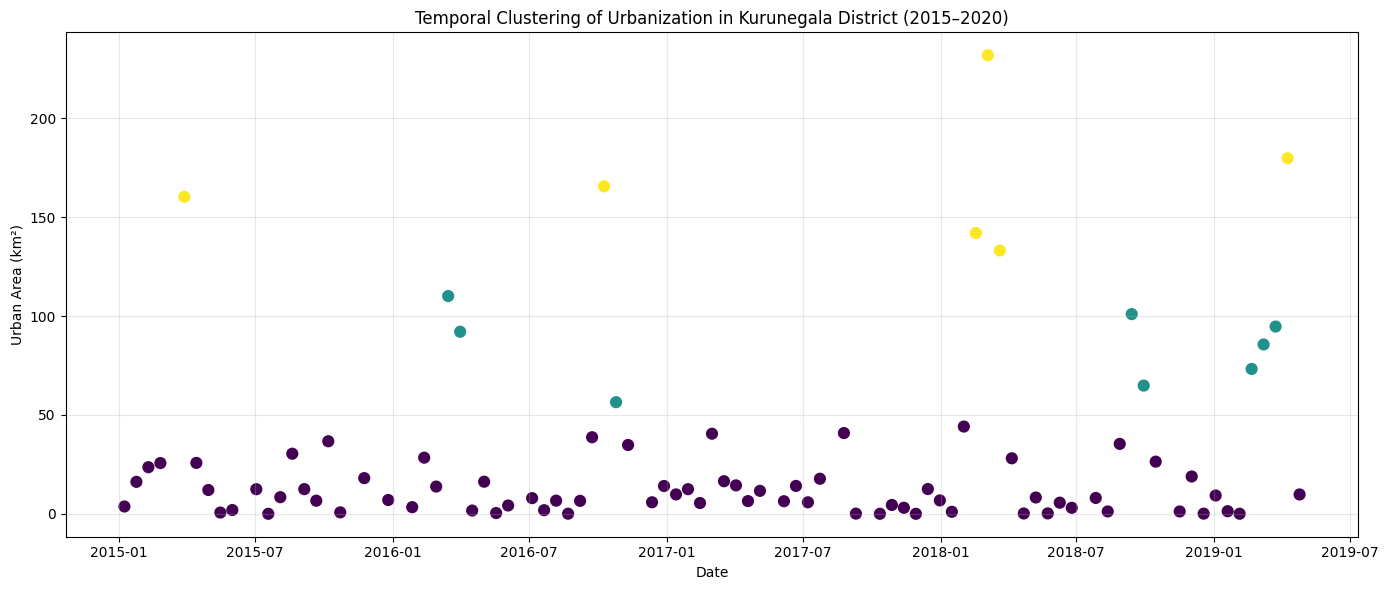


Model Comparison Results (monthly data):
           Model        MAE       RMSE        R²
0        Prophet  53.891388  66.041103 -0.608169
1          ARIMA  41.342403  55.965245 -0.154888
2  Random Forest  48.231703  66.768364 -0.643783

Best Performing Model: ARIMA


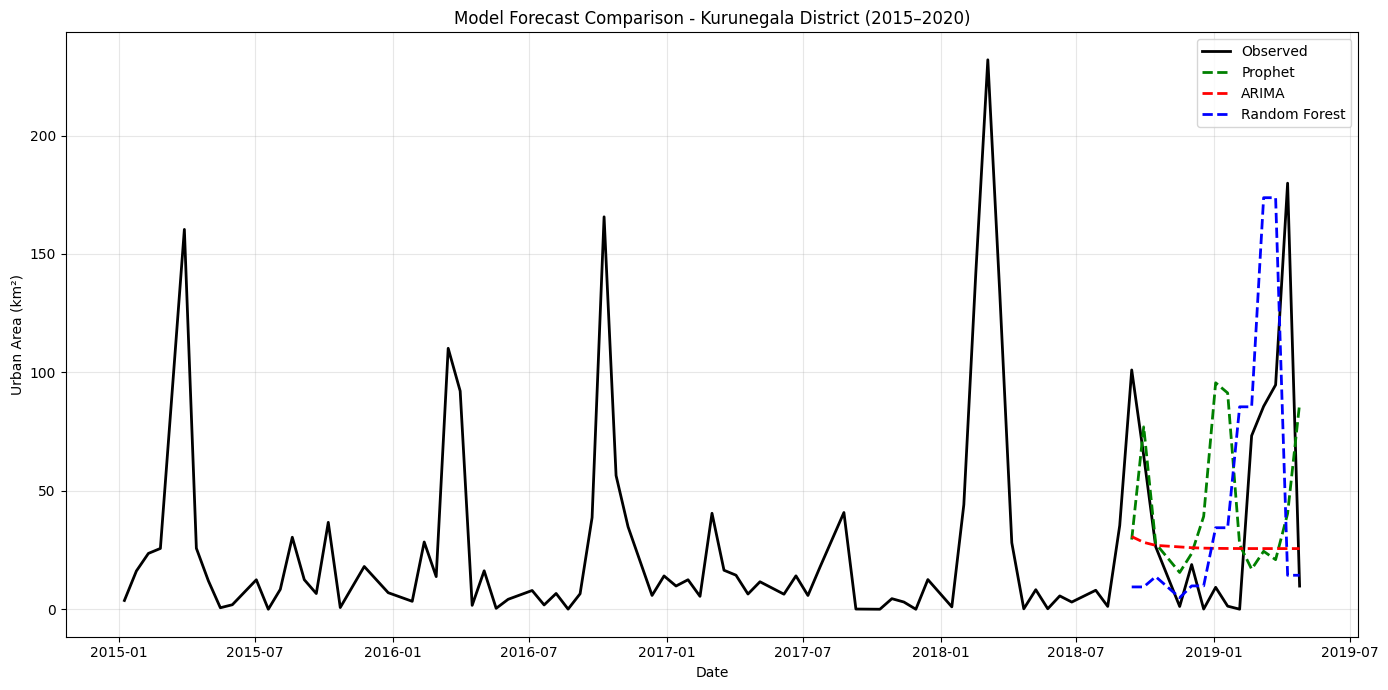

11:48:54 - cmdstanpy - INFO - Chain [1] start processing



Generating future predictions after 2020...


11:48:54 - cmdstanpy - INFO - Chain [1] done processing


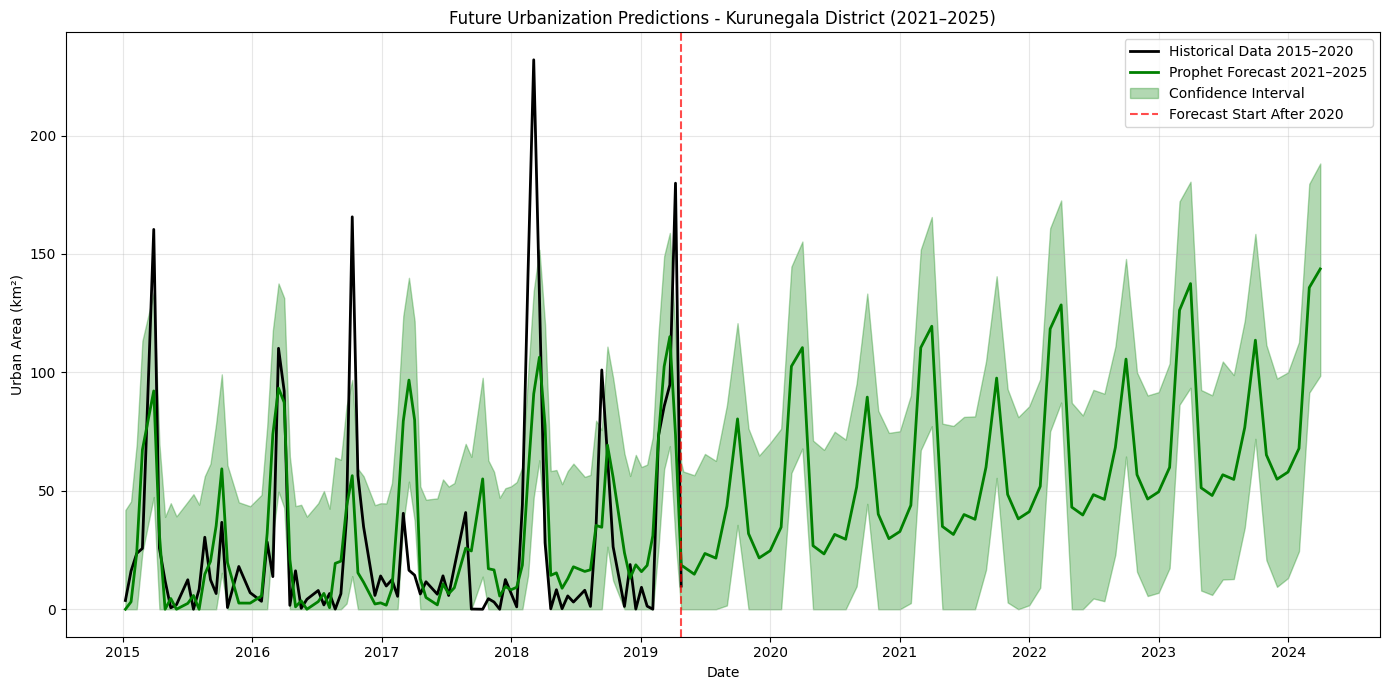


Model comparison and prediction complete!
Study area: Kurunegala
Historical data: 2015–2020
Prediction period: 2021–2025
Results saved in: C:\project IP\prediction output


In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURATION
# =====================================================

STUDY_AREA = "Kurunegala"

PROCESSED_DIR = Path("C:\\project IP\\urbanizationoutput")

MONTHLY_FILE = PROCESSED_DIR / "C:\\project IP\\urbanizationoutput\\Urbanization_Stats_2015_2020.csv"

OUTPUT_DIR = Path("C:\\project IP\\prediction output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =====================================================
# LOAD DATA
# =====================================================

def load_urbanization_data():
    if MONTHLY_FILE.exists():
        print(f"Loading data from: {MONTHLY_FILE}")

        df = pd.read_csv(MONTHLY_FILE, parse_dates=["Date"])
        df = df.sort_values("Date")

        print(f"Loaded {len(df)} records")
        print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")

        return df, "monthly"

    else:
        raise FileNotFoundError(f"CSV file not found: {MONTHLY_FILE}")

df, data_type = load_urbanization_data()

# Keep only 2015–2020 data
df = df[(df["Year"] >= 2015) & (df["Year"] <= 2020)].copy()

if len(df) < 5:
    raise ValueError("Not enough records found for prediction model!")

print(f"\nUsing {STUDY_AREA} urbanization data from 2015 to 2020")
print(f"Total records: {len(df)}")

# =====================================================
# TRAIN / TEST SPLIT
# =====================================================

train_size = int(len(df) * 0.85)

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

y_train = train_df["Urban_Area_km2"]
y_test = test_df["Urban_Area_km2"]

X_train_index = train_df["Date"]
X_test_index = test_df["Date"]

print(f"\nTrain/Test Split: {len(train_df)} training, {len(test_df)} testing records")

# =====================================================
# 1. PROPHET MODEL
# =====================================================

print("\nTraining Prophet...")

prophet_df = train_df[["Date", "Urban_Area_km2"]].rename(
    columns={
        "Date": "ds",
        "Urban_Area_km2": "y"
    }
)

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.3
)

model_prophet.fit(prophet_df)

freq = "MS"

future = model_prophet.make_future_dataframe(
    periods=len(test_df),
    freq=freq
)

forecast = model_prophet.predict(future)

prophet_forecast = forecast.tail(len(test_df))

prophet_pred = prophet_forecast["yhat"].values
prophet_pred = np.clip(prophet_pred, 0, None)

prophet_mae = mean_absolute_error(y_test, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(y_test, prophet_pred))
prophet_r2 = r2_score(y_test, prophet_pred)

print(f"Prophet → MAE: {prophet_mae:.3f}, RMSE: {prophet_rmse:.3f}, R²: {prophet_r2:.3f}")

# =====================================================
# 2. ARIMA MODEL
# =====================================================

print("\nTraining ARIMA...")

try:
    arima_model = ARIMA(y_train, order=(1, 1, 1))
    arima_fit = arima_model.fit()

    arima_forecast = arima_fit.forecast(steps=len(y_test))
    arima_forecast = np.clip(arima_forecast, 0, None)

    arima_mae = mean_absolute_error(y_test, arima_forecast)
    arima_rmse = np.sqrt(mean_squared_error(y_test, arima_forecast))
    arima_r2 = r2_score(y_test, arima_forecast)

    print(f"ARIMA(1,1,1) → MAE: {arima_mae:.3f}, RMSE: {arima_rmse:.3f}, R²: {arima_r2:.3f}")

except Exception as e:
    print(f"ARIMA model failed: {str(e)}")

    window = min(12, len(y_train))

    arima_forecast = np.full(
        len(y_test),
        y_train.rolling(window=window).mean().iloc[-1]
    )

    arima_forecast = np.clip(arima_forecast, 0, None)

    arima_mae = mean_absolute_error(y_test, arima_forecast)
    arima_rmse = np.sqrt(mean_squared_error(y_test, arima_forecast))
    arima_r2 = r2_score(y_test, arima_forecast)

    print(f"Moving Average fallback → MAE: {arima_mae:.3f}, RMSE: {arima_rmse:.3f}, R²: {arima_r2:.3f}")

# =====================================================
# 3. RANDOM FOREST MODEL
# =====================================================

print("\nTraining Random Forest...")

df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["Quarter"] = df["Date"].dt.quarter
df["DayOfYear"] = df["Date"].dt.dayofyear

feature_cols = [
    "Month",
    "Year",
    "Quarter"
]

X = df[feature_cols]
y = df["Urban_Area_km2"]

X_train_rf = X.iloc[:train_size]
X_test_rf = X.iloc[train_size:]

y_train_rf = y.iloc[:train_size]
y_test_rf = y.iloc[train_size:]

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train_rf, y_train_rf)

rf_pred = rf.predict(X_test_rf)
rf_pred = np.clip(rf_pred, 0, None)

rf_mae = mean_absolute_error(y_test_rf, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_pred))
rf_r2 = r2_score(y_test_rf, rf_pred)

print(f"Random Forest → MAE: {rf_mae:.3f}, RMSE: {rf_rmse:.3f}, R²: {rf_r2:.3f}")

# =====================================================
# 4. K-MEANS CLUSTERING
# =====================================================

print("\nRunning K-Means clustering...")

X_scaled = StandardScaler().fit_transform(
    df[["Urban_Area_km2"]]
)

kmeans = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(14, 6))

plt.scatter(
    df["Date"],
    df["Urban_Area_km2"],
    c=df["Cluster"],
    s=60
)

plt.title(f"Temporal Clustering of Urbanization in {STUDY_AREA} District (2015–2020)")
plt.xlabel("Date")
plt.ylabel("Urban Area (km²)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "KMeans_Temporal_Clusters_2015_2020.png",
    dpi=200
)

plt.show()

df.to_csv(
    OUTPUT_DIR / "KMeans_Clusters_2015_2020.csv",
    index=False
)

# =====================================================
# 5. MODEL COMPARISON
# =====================================================

results = pd.DataFrame({
    "Model": ["Prophet", "ARIMA", "Random Forest"],
    "MAE": [prophet_mae, arima_mae, rf_mae],
    "RMSE": [prophet_rmse, arima_rmse, rf_rmse],
    "R²": [prophet_r2, arima_r2, rf_r2]
})

print(f"\nModel Comparison Results ({data_type} data):")
print(results)

results.to_csv(
    OUTPUT_DIR / "Model_Comparison_Results_2015_2020.csv",
    index=False
)

best_model = results.loc[
    results["RMSE"].idxmin(),
    "Model"
]

print(f"\nBest Performing Model: {best_model}")

# =====================================================
# 6. VISUALIZE FORECASTS
# =====================================================

plt.figure(figsize=(14, 7))

plt.plot(
    df["Date"],
    df["Urban_Area_km2"],
    label="Observed",
    color="black",
    linewidth=2
)

plt.plot(
    X_test_index,
    prophet_pred,
    "g--",
    label="Prophet",
    linewidth=2
)

plt.plot(
    X_test_index,
    arima_forecast,
    "r--",
    label="ARIMA",
    linewidth=2
)

plt.plot(
    X_test_index,
    rf_pred,
    "b--",
    label="Random Forest",
    linewidth=2
)

plt.title(f"Model Forecast Comparison - {STUDY_AREA} District (2015–2020)")
plt.xlabel("Date")
plt.ylabel("Urban Area (km²)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "Model_Forecast_Comparison_2015_2020.png",
    dpi=200
)

plt.show()

# =====================================================
# 7. FUTURE PREDICTION AFTER 2020
# =====================================================

print("\nGenerating future predictions after 2020...")

# Train Prophet again using all 2015–2020 data
prophet_full_df = df[["Date", "Urban_Area_km2"]].rename(
    columns={
        "Date": "ds",
        "Urban_Area_km2": "y"
    }
)

future_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.3
)

future_model.fit(prophet_full_df)

# Predict 2021–2025
future_periods = 60

future_df = future_model.make_future_dataframe(
    periods=future_periods,
    freq="MS"
)

future_forecast = future_model.predict(future_df)

# Remove negative prediction values
future_forecast["yhat"] = future_forecast["yhat"].clip(lower=0)
future_forecast["yhat_lower"] = future_forecast["yhat_lower"].clip(lower=0)
future_forecast["yhat_upper"] = future_forecast["yhat_upper"].clip(lower=0)

future_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].to_csv(
    OUTPUT_DIR / "Future_Predictions_2021_2025.csv",
    index=False
)

plt.figure(figsize=(14, 7))

plt.plot(
    df["Date"],
    df["Urban_Area_km2"],
    label="Historical Data 2015–2020",
    color="black",
    linewidth=2
)

plt.plot(
    future_forecast["ds"],
    future_forecast["yhat"],
    "g-",
    label="Prophet Forecast 2021–2025",
    linewidth=2
)

plt.fill_between(
    future_forecast["ds"],
    future_forecast["yhat_lower"],
    future_forecast["yhat_upper"],
    alpha=0.3,
    color="green",
    label="Confidence Interval"
)

plt.axvline(
    x=df["Date"].max(),
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Forecast Start After 2020"
)

plt.title(f"Future Urbanization Predictions - {STUDY_AREA} District (2021–2025)")
plt.xlabel("Date")
plt.ylabel("Urban Area (km²)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "Future_Predictions_2021_2025.png",
    dpi=200
)

plt.show()

print(f"\nModel comparison and prediction complete!")
print(f"Study area: {STUDY_AREA}")
print(f"Historical data: 2015–2020")
print(f"Prediction period: 2021–2025")
print(f"Results saved in: {OUTPUT_DIR}")

11:49:52 - cmdstanpy - INFO - Chain [1] start processing
11:49:53 - cmdstanpy - INFO - Chain [1] done processing


Forecast saved → Kurunegala_Urbanization_Forecast_monthly_2021_2025.csv


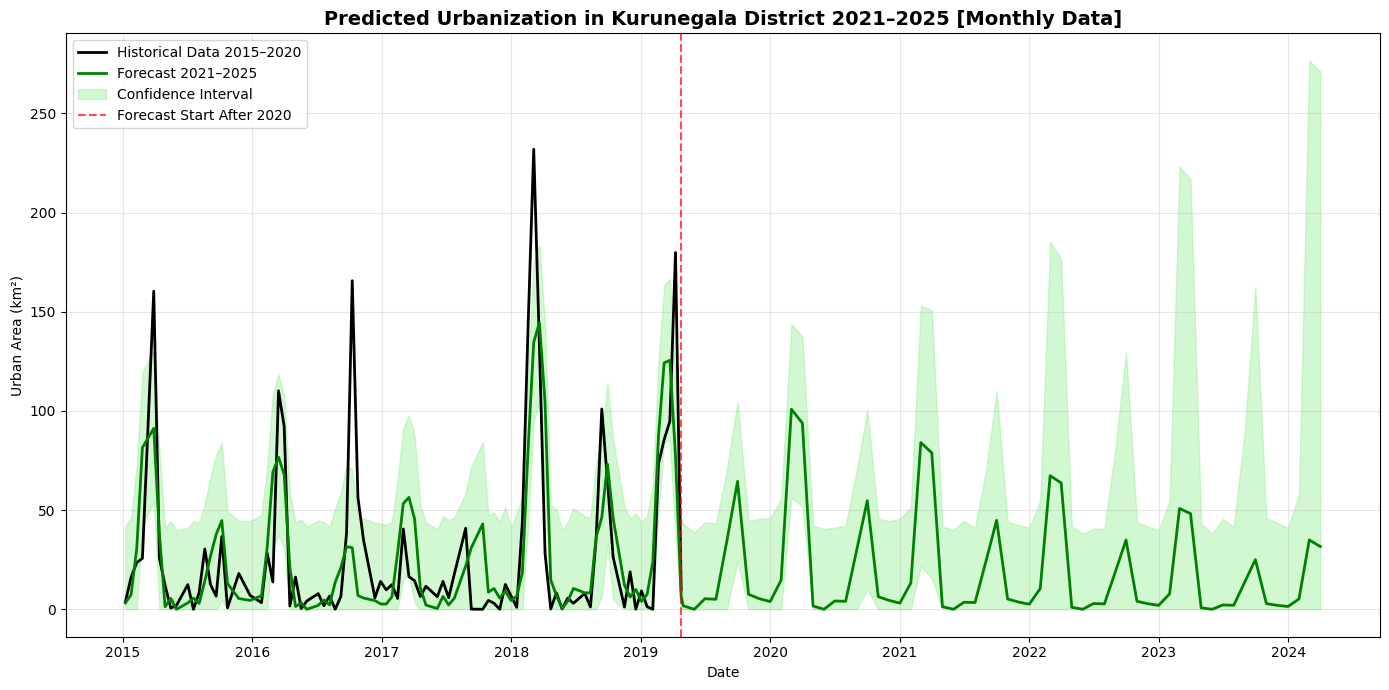


Predicted Urban Area in 2025: 31.65 km²
Growth from 2019 to 2025:
21.87 km² (223.51% increase)


In [2]:
# =====================================================
# FINAL MODEL BUILDING & LONG-TERM FORECAST (2021–2025)
# =====================================================

# Retrain Prophet with full 2015–2020 data
prophet_full_df = df[["Date", "Urban_Area_km2"]].rename(
    columns={
        "Date": "ds",
        "Urban_Area_km2": "y"
    }
)

final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.3,
    seasonality_mode="multiplicative"
)

final_model.fit(prophet_full_df)

# Forecast 5 more years after 2020
# 2021–2025 = 60 months
future_months = 60

future_full = final_model.make_future_dataframe(
    periods=future_months,
    freq=freq
)

future_forecast = final_model.predict(future_full)

# Prevent negative urban area predictions
future_forecast["yhat"] = future_forecast["yhat"].clip(lower=0)
future_forecast["yhat_lower"] = future_forecast["yhat_lower"].clip(lower=0)
future_forecast["yhat_upper"] = future_forecast["yhat_upper"].clip(lower=0)

# Save results
forecast_output = future_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
]

forecast_output.to_csv(
    os.path.join(
        OUTPUT_DIR,
        f"Kurunegala_Urbanization_Forecast_{data_type}_2021_2025.csv"
    ),
    index=False
)

print(
    f"Forecast saved → Kurunegala_Urbanization_Forecast_{data_type}_2021_2025.csv"
)

# Plot forecast
plt.figure(figsize=(14, 7))

plt.plot(
    prophet_full_df["ds"],
    prophet_full_df["y"],
    label="Historical Data 2015–2020",
    color="black",
    linewidth=2
)

plt.plot(
    future_forecast["ds"],
    future_forecast["yhat"],
    "g-",
    linewidth=2,
    label="Forecast 2021–2025"
)

plt.fill_between(
    future_forecast["ds"],
    future_forecast["yhat_lower"],
    future_forecast["yhat_upper"],
    color="lightgreen",
    alpha=0.4,
    label="Confidence Interval"
)

plt.axvline(
    x=prophet_full_df["ds"].max(),
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Forecast Start After 2020"
)

plt.title(
    f"Predicted Urbanization in Kurunegala District 2021–2025 [{data_type.title()} Data]",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Urban Area (km²)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        f"Kurunegala_Urbanization_Forecast_2021_2025_{data_type}.png"
    ),
    dpi=200
)

plt.show()

# Estimate total predicted growth
last_known = prophet_full_df["y"].iloc[-1]

predicted_2025 = future_forecast["yhat"].iloc[-1]

growth = predicted_2025 - last_known

rate = (growth / last_known) * 100

print(f"\nPredicted Urban Area in 2025: {predicted_2025:.2f} km²")

print(f"Growth from {prophet_full_df['ds'].max().year} to 2025:")

if growth >= 0:
    print(f"{growth:.2f} km² ({rate:.2f}% increase)")
else:
    print(f"{abs(growth):.2f} km² ({abs(rate):.2f}% decrease)")